Pass 组数量: 32
Fail 组数量: 6


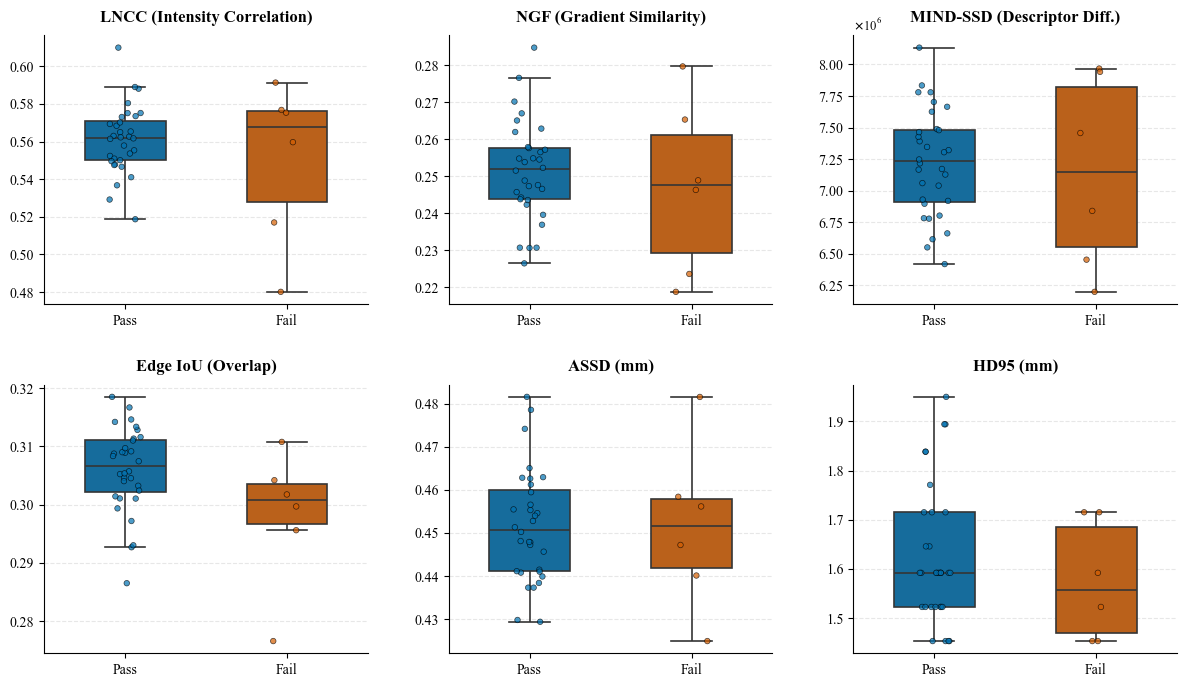

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import ticker
import numpy as np

# ==========================================
# 1. 绘图风格设置 (保持不变)
# ==========================================
def set_pub_style():
    plt.rcParams.update({
        "font.family": "serif",
        "font.serif": ["Times New Roman", "DejaVu Serif", "Liberation Serif"],
        "font.size": 11,
        "axes.labelsize": 11,
        "axes.titlesize": 12,
        "legend.fontsize": 10,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "lines.linewidth": 1.2,
        "axes.grid": True,
        "grid.alpha": 0.3,
        "grid.linestyle": "--",
        "figure.figsize": (12, 7),
        "axes.spines.top": False,
        "axes.spines.right": False,
    })

# ==========================================
# 2. 数据处理逻辑 (保持不变)
# ==========================================
def load_and_process_data(csv_path):
    df = pd.read_csv(csv_path)
    # 过滤 MPRAGE
    df_filtered = df[~df['modality_name'].str.contains('MPRAGE', case=False, na=False)].copy()
    
    # 定义 Fail Subjects
    fail_substrings = [
        'OHC_13', 'YHC_02', 'YHC_04', 
        'PDP_01', 'PDP_03', 'PDP_04'
    ]
    
    # 按受试者聚合
    metrics = ['mean_lncc', 'mean_ngf', 'mind_ssd', 'edge_iou', 'assd_mm', 'hd95_mm']
    df_subject = df_filtered.groupby('Subject_ID')[metrics].median().reset_index()
    
    # 分配组别
    def assign_group(subject_id):
        for fail_tag in fail_substrings:
            if fail_tag in subject_id:
                return 'Fail'
        return 'Pass'
    
    df_subject['Group'] = df_subject['Subject_ID'].apply(assign_group)
    return df_subject

# ==========================================
# 3. 绘图主逻辑 (已修复警告)
# ==========================================
def plot_qc_distributions(df):
    set_pub_style()
    
    metric_map = {
        'mean_lncc': ('LNCC (Intensity Correlation)', False),
        'mean_ngf':  ('NGF (Gradient Similarity)', False),
        'mind_ssd':  ('MIND-SSD (Descriptor Diff.)', True),
        'edge_iou':  ('Edge IoU (Overlap)', False),
        'assd_mm':   ('ASSD (mm)', False),
        'hd95_mm':   ('HD95 (mm)', False)
    }
    
    fig, axes = plt.subplots(2, 3, figsize=(12, 7))
    axes = axes.flatten()
    
    palette = {"Pass": "#0072B2", "Fail": "#D55E00"} 
    order = ["Pass", "Fail"]
    
    for i, (col, (title, use_sci)) in enumerate(metric_map.items()):
        ax = axes[i]
        
        # === 修复点在这里 ===
        # 1. Boxplot: 增加 hue='Group' 和 legend=False
        sns.boxplot(
            x='Group', y=col, hue='Group',  # <--- 显式指定 hue
            data=df, order=order, ax=ax,
            palette=palette, width=0.5, linewidth=1.2, 
            fliersize=0, legend=False       # <--- 关闭图例
        )
        
        # 2. Stripplot: 同样增加 hue='Group' 和 legend=False
        sns.stripplot(
            x='Group', y=col, hue='Group',  # <--- 显式指定 hue
            data=df, order=order, ax=ax,
            palette=palette, size=4, alpha=0.7, 
            jitter=True, dodge=False, edgecolor='black', linewidth=0.5,
            legend=False                    # <--- 关闭图例
        )
        
        ax.set_title(title, fontweight='bold', pad=10)
        ax.set_xlabel('')
        ax.set_ylabel('')
        
        if use_sci:
            ax.yaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
            ax.ticklabel_format(style='sci', axis='y', scilimits=(0,0))
            ax.yaxis.get_offset_text().set_fontsize(9)
            
    plt.tight_layout()
    plt.subplots_adjust(hspace=0.3, wspace=0.25)
    plt.show()

# ==========================================
# 4. 执行
# ==========================================
csv_file = '/Users/jannik/Library/CloudStorage/OneDrive-个人/Study-Materials-and-Documents/Master/Masterarbeit/撰写/qc_analysis_results_batch_zip/Thesis_Data_All_Metrics.csv'


try:
    df_processed = load_and_process_data(csv_file)
    print("Pass 组数量:", len(df_processed[df_processed['Group']=='Pass']))
    print("Fail 组数量:", len(df_processed[df_processed['Group']=='Fail']))
    plot_qc_distributions(df_processed)
except FileNotFoundError:
    print(f"错误: 找不到文件 {csv_file}，请确保文件在当前目录中。")
